### Własna implementacja algorytmu PSO: 

In [23]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import sys
import seaborn as sns
import pandas as pd


class Particle:
    def __init__(self, position, bounds, w, c1, c2):
        self.position = np.array(position, dtype=float)
        self.bounds = bounds
        self.dim = len(position)
        
        # Inicjalizacja prędkości - proporcjonalna do zakresu parametrów
        # ULEPSZENIE 1: Większa początkowa prędkość dla lepszej eksploracji
        range_per_dim = np.array([(b[1] - b[0]) for b in bounds])
        self.v = np.random.uniform(-0.15, 0.15, self.dim) * range_per_dim
        
        # Maksymalna prędkość (20% zakresu każdego wymiaru)
        # ULEPSZENIE 2: Ograniczenie maksymalnej prędkości
        self.v_max = 0.2 * range_per_dim
        
        self.best_position = self.position.copy()
        self.best_value = float('inf')
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.stagnation_counter = 0  # ULEPSZENIE 3: Licznik stagnacji

    def update_velocity(self, global_best_position, current_w, current_c1, current_c2):
        r1 = np.random.rand(self.dim)
        r2 = np.random.rand(self.dim)

        own_component = current_c1 * r1 * (self.best_position - self.position)
        global_component = current_c2 * r2 * (global_best_position - self.position)

        self.v = current_w * self.v + own_component + global_component
        
        # ULEPSZENIE 4: Ograniczenie prędkości do v_max
        self.v = np.clip(self.v, -self.v_max, self.v_max)

    def update_position(self):
        new_position = self.position + self.v
        
        for i, (lower, upper) in enumerate(self.bounds):
            if new_position[i] < lower:
                new_position[i] = lower
                self.v[i] = -self.v[i] * np.random.uniform(0.3, 0.7)
            elif new_position[i] > upper:
                new_position[i] = upper
                self.v[i] = -self.v[i] * np.random.uniform(0.3, 0.7)
        
        self.position = new_position

    def evaluate(self, goal_func, args=()):
        position_value = goal_func(self.position, *args)
        
        if position_value < self.best_value:
            self.best_value = position_value
            self.best_position = self.position.copy()
            self.stagnation_counter = 0  
        else:
            self.stagnation_counter += 1
        
        return position_value
    
    def reinitialize(self, bounds):
        """ULEPSZENIE 7: Reinicjalizacja zagubionej cząstki"""
        self.position = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
        range_per_dim = np.array([(b[1] - b[0]) for b in bounds])
        self.v = np.random.uniform(-0.15, 0.15, self.dim) * range_per_dim
        self.stagnation_counter = 0


def pso_algorithm_anfis(goal_func, bounds, args=(), num_particles=20, max_iter=50, 
                       w=1.0, c1=2.0, c2=2.0, 
                       c1_increase_to=2.5, c2_increase_to=2.5, 
                       increase_after_percent=0.5):
    """
    Algorytm PSO dostosowany do ANFIS ze zwiększaniem c1 i c2.
    WERSJA ULEPSZONA z lepszą eksploracją i reinicjalizacją.
    
    Args:
        goal_func: funkcja celu do minimalizacji (przyjmuje position i *args)
        bounds: lista krotek (min, max) dla każdego wymiaru
        args: dodatkowe argumenty dla funkcji celu (np. obiekt ANFIS)
        num_particles: liczba cząstek w roju
        max_iter: maksymalna liczba iteracji
        w: początkowy współczynnik inercji
        c1: początkowy współczynnik poznawczy
        c2: początkowy współczynnik socjalny
        c1_increase_to: docelowa wartość c1 (po zwiększeniu)
        c2_increase_to: docelowa wartość c2 (po zwiększeniu)
        increase_after_percent: po jakim procencie iteracji zwiększyć c1 i c2
    
    Returns:
        PSOResult: obiekt z polami x, fun, nfev, nit
        history: lista najlepszych wartości w każdej iteracji
    """
    
    def actualize_w(iteration, max_iterations, w_max=1.0, w_min=0.1):
        """Liniowo malejący współczynnik inercji"""
        return w_max - ((w_max - w_min) * (iteration / max_iterations))
    
    # ULEPSZENIE 8: Inicjalizacja z lepszym rozkładem
    particles = []
    for _ in range(num_particles):
        position = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
        particle = Particle(position, bounds, w, c1, c2)
        particles.append(particle)
    
    # ULEPSZENIE 9: Ewaluacja początkowa wszystkich cząstek
    global_best_position = None
    global_best_value = float('inf')
    
    for particle in particles:
        value = particle.evaluate(goal_func, args)
        if value < global_best_value:
            global_best_value = value
            global_best_position = particle.position.copy()
    
    min_history = []
    increase_iter = int(max_iter * increase_after_percent)
    stagnation_threshold = max(10, max_iter // 2)  # ULEPSZENIE 10: Próg reinicjalizacji
    no_improvement_counter = 0
    
    for iteration in range(max_iter):
        current_w = actualize_w(iteration, max_iter, w_max=w, w_min=0.1)
        
        if iteration < increase_iter:
            current_c1 = c1
            current_c2 = c2
        else:
            # Liniowe zwiększanie od c1/c2 do c1_increase_to/c2_increase_to
            progress = (iteration - increase_iter) / (max_iter - increase_iter)
            current_c1 = c1 + (c1_increase_to - c1) * progress
            current_c2 = c2 + (c2_increase_to - c2) * progress
        
        prev_best = global_best_value
        
        # ULEPSZENIE 11: Najpierw aktualizacja pozycji, potem ewaluacja
        for particle in particles:
            particle.update_velocity(global_best_position, current_w, current_c1, current_c2)
            particle.update_position()
        
        # Ewaluacja
        for particle in particles:
            value = particle.evaluate(goal_func, args)
            
            if value < global_best_value:
                global_best_value = value
                global_best_position = particle.position.copy()
        
        # ULEPSZENIE 12: Reinicjalizacja zagubionych cząstek
        if iteration > 0 and iteration % stagnation_threshold == 0:
            print(f"Reinicjalizacja zagubionych cząstek... po {iteration} iteracjach")
            for particle in particles:
                if particle.stagnation_counter > stagnation_threshold:
                    particle.reinitialize(bounds)
        
        # Śledzenie stagnacji globalnej
        if abs(prev_best - global_best_value) < 1e-10:
            no_improvement_counter += 1
        else:
            no_improvement_counter = 0
        
        # ULEPSZENIE 13: Restart całego roju jeśli brak postępu
        if no_improvement_counter > max(20, max_iter // 10):
            worst_particles = sorted(particles, key=lambda p: p.best_value, reverse=True)
            num_to_reinit = num_particles // 3  # Reinicjalizuj 1/3 najgorszych
            for i in range(num_to_reinit):
                worst_particles[i].reinitialize(bounds)
            no_improvement_counter = 0
        
        min_history.append(global_best_value)
        
        if (iteration % 100 == 0 or iteration == max_iter - 1):
            print(f"Iteracja {iteration}/{max_iter}: "
                  f"Najlepszy błąd = {global_best_value:.6f}, "
                  f"w = {current_w:.3f}, c1 = {current_c1:.3f}, c2 = {current_c2:.3f}")
    
    print(f"\nOptymalizacja PSO zakończona!")
    print(f"Najlepszy błąd: {global_best_value:.6f}")
    print(f"Liczba iteracji: {max_iter}")
    print(f"Liczba ewaluacji funkcji: {max_iter * num_particles}")
    
    class PSOResult:
        def __init__(self, x, fun, nfev, nit):
            self.x = x
            self.fun = fun
            self.nfev = nfev
            self.nit = nit
    
    result = PSOResult(
        x=global_best_position,
        fun=global_best_value,
        nfev=max_iter * num_particles,
        nit=max_iter
    )
    
    return result, min_history


In [24]:
# -*- coding: utf-8 -*-
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from operators import productN
import numpy as np
#from helps_and_enhancers import *
import matplotlib.pyplot as plt
# from ANFIS import ANFIS
import time
import copy
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

import numpy as np
from scipy.optimize import minimize, basinhopping
from scipy.stats import variation
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import permutations, combinations
import time
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from helps_and_enhancers import calculate_combinations, my_reshape
from operators import productN
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids

from goal_function_object import *

def productN(args, op):
    return np.prod(args, axis=0)
    

class ANFIS:
    
    def __init__(self, inputs, training_data: np.ndarray, expected_labels: np.ndarray, operator_function=productN, operator_init_value=0.5):
        self.input_list = inputs
        self.input_number = len(inputs)
        self.training_data = training_data
        self.expected_labels = expected_labels
        
        self.premises = []
        for i in range(self.input_number):
            self.premises.append(self.input_list[i].get())

        self.nodes_number = np.prod([inp.n_functions for inp in self.input_list])
        
        self.operator_function=operator_function
        
        #self.tsk = np.ones((self.nodes_number ,self.input_number+1))
        self.tsk = np.random.random((self.nodes_number ,self.input_number+1))
        
        self.op  = [operator_init_value]*self.nodes_number

        self.calculate_aids()

    #Wyswietlanie funkcji przynależnosci
    def show_inputs(self):
        plt.figure()
        for i in range(self.input_number):
            plt.subplot(self.input_number, 1, i+1)
            self.input_list[i].show()
            plt.legend()
        plt.show()

    def set_premises_parameters(self, fv):
        fv = np.array(fv).reshape(np.shape(self.premises))
        self.premises=fv
        for i in range(self.input_number):
            self.input_list[i].set(*fv[i])
             
    def calculate_aids(self):
        self.premises_combinations = np.array(calculate_combinations(self))[:,::-1]

    def output_to_labels(self, y_pred):
        rounded = np.round(y_pred.flatten()).astype(int)
        r_shape = np.shape(rounded)
        return np.max((np.min((rounded , np.ones(r_shape)),axis=0), np.zeros(r_shape)),axis=0)#clamp 0-1       
               
    def anfis_estimate_labels(self, fv, op, tsk) -> np.ndarray:

        data = self.training_data

        self.set_premises_parameters(fv)
        tsk=np.reshape(tsk,np.shape(self.tsk))
        memberships = [self.input_list[x].fuzzify(data[x]) for x in range(self.input_number)]
        
        #Wnioskowanie
        arguments = []
        for premises in self.premises_combinations:
            item = []
            for i in range(len(premises)):
                item.append(np.array(memberships[i])[:,premises[i]])
            arguments.append(   item  )

        arguments = np.transpose(arguments, (1,2,0))
        
        R=self.operator_function(arguments, op)
        
        #Normalizacja normalizacja poziomów aktywacji reguł
        Rsum = np.sum(R, axis=1, keepdims=True)

        Rnorm = R / Rsum
        Rnorm[(Rsum==0).flatten(),:] = 0
        # wylicz wartoci przesłanek dla każdej próbki
        
        dataXYZ1 = np.vstack((self.training_data,np.ones(len(self.training_data[0])))).T
        Q = np.dot(dataXYZ1, tsk.T) 
        
        # wyznacz wyniki wnioskowania dla każdej próbki
        result = (Q * Rnorm).sum(axis=1, keepdims=True)
    
        return result.T    
        
    def show_results(self, color=None):
        
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        if color is None:
            color = [[1,0,0] if cc else [0,1,0] for cc in self.expected_labels]

        result = self.anfis_estimate_labels(self.premises,self.op,self.tsk)
        
        #ax.scatter(np.array(self.training_data)[:,0], np.array(self.training_data)[:,1], result, c=rgb)
        ax.scatter(self.training_data[0], self.training_data[1], result, c=color)
        
        plt.show()
    
    def set_training_and_testing_data(self, training_data, expected_labels):
        self.training_data = training_data
        self.expected_labels = expected_labels
        
    def train(self, global_optimization: bool, learn_premises: bool, learn_operators: bool, learn_consequents: bool, 
              n_iter=100, bounds_premises=None, use_pso_algorithm=False, pso_pop_size=50, c_bounds=(2, 2.5), pso_w=1.0):
    
        x1 = [ item for sublist in self.premises for item in sublist ]
        x1 = np.array(x1).flatten()
        x2 = self.op
        x3 = self.tsk.flatten()
          
        if bounds_premises is None:
            bfv = [(0,4)]*len(x1)
        else:
            bfv = bounds_premises
        bop  = [(0.0,2.0)]*len(x2)
        btsk = [(0,2)]*len(x3)
        
        niter_success=100
            
        if learn_premises and learn_operators and learn_consequents:
            x0 = np.hstack((x1,x2,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop + btsk
            
            if use_pso_algorithm:
                res, fitness_history = pso_algorithm_anfis(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    num_particles=pso_pop_size,
                    max_iter=n_iter,
                    w=pso_w,
                    c1=c_bounds[0],
                    c2=c_bounds[0],
                    c1_increase_to=c_bounds[1],
                    c2_increase_to=c_bounds[1],
                    increase_after_percent=0.5,
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises and learn_operators:
            x0 = np.hstack((x1,x2))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop

            if use_pso_algorithm:
                res, fitness_history = pso_algorithm_anfis(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    num_particles=pso_pop_size,
                    max_iter=n_iter,
                    w=pso_w,
                    c1=c_bounds[0],
                    c2=c_bounds[0],
                    c1_increase_to=c_bounds[1],
                    c2_increase_to=c_bounds[1],
                    increase_after_percent=0.5,
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]

        elif learn_premises and learn_consequents:
            x0 = np.hstack((x1,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv + btsk

            if use_pso_algorithm:
                res, fitness_history = pso_algorithm_anfis(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    num_particles=pso_pop_size,
                    max_iter=n_iter,
                    w=pso_w,
                    c1=c_bounds[0],
                    c2=c_bounds[0],
                    c1_increase_to=c_bounds[1],
                    c2_increase_to=c_bounds[1],
                    increase_after_percent=0.5,
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter)#, niter_success=niter_success)
            else:
                res = minimize(goal_premises_consequents, x0, method='SLSQP', bounds=bounds, args=self, tol=1e-6)

            self.set_premises_parameters(res.x[:self.end_x1]) ##zmiana funkcji
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))

        elif learn_operators and learn_consequents:
            x0 = np.hstack((x2,x3))
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop + btsk

            if use_pso_algorithm:
                res, fitness_history = pso_algorithm_anfis(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    num_particles=pso_pop_size,
                    max_iter=n_iter,
                    w=pso_w,
                    c1=c_bounds[0],
                    c2=c_bounds[0],
                    c1_increase_to=c_bounds[1],
                    c2_increase_to=c_bounds[1],
                    increase_after_percent=0.5,
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
        
        elif learn_premises:
            x0 = x1
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv

            if use_pso_algorithm:
                res, fitness_history = pso_algorithm_anfis(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    num_particles=pso_pop_size,
                    max_iter=n_iter,
                    w=pso_w,
                    c1=c_bounds[0],
                    c2=c_bounds[0],
                    c1_increase_to=c_bounds[1],
                    c2_increase_to=c_bounds[1],
                    increase_after_percent=0.5,
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:].reshape(np.shape(self.premises)))

        elif learn_operators:
            x0 = x2
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop

            if use_pso_algorithm:
                res, fitness_history = pso_algorithm_anfis(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    num_particles=pso_pop_size,
                    max_iter=n_iter,
                    w=pso_w,
                    c1=c_bounds[0],
                    c2=c_bounds[0],
                    c1_increase_to=c_bounds[1],
                    c2_increase_to=c_bounds[1],
                    increase_after_percent=0.5,
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[:]
            
        elif learn_consequents:
            x0 = x3
            self.end_x1 = 0
            self.end_x2 = 0
            
            bounds = btsk

            if use_pso_algorithm:
                res, fitness_history = pso_algorithm_anfis(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    num_particles=pso_pop_size,
                    max_iter=n_iter,
                    w=pso_w,
                    c1=c_bounds[0],
                    c2=c_bounds[0],
                    c1_increase_to=c_bounds[1],
                    c2_increase_to=c_bounds[1],
                    increase_after_percent=0.5,
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self), "tol":1e-03}
                res = basinhopping(goal_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.tsk=res.x[:].reshape(np.shape(self.tsk))
            
        else:
            print("Error")
            assert(0)
            
        print("Optymalizacja zakończona!")
        print("z blędem:  ", res.fun)
        print("Liczba ew: ", res.nfev)
        print("Liczba it: ", res.nit)

        return fitness_history


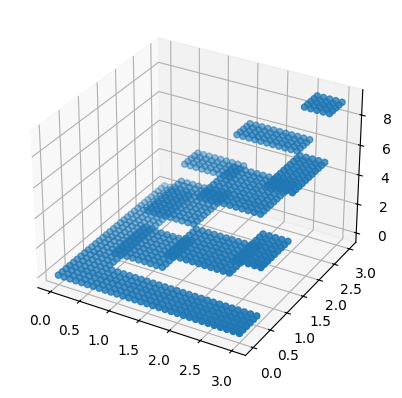


Parametry przed uczeniem:
Premises shape: (2, 3, 4)
Operators length: 9
TSK shape: (9, 3)
Iteracja 0/6000: Najlepszy błąd = 708.169346, w = 1.000, c1 = 1.800, c2 = 1.800


C:\Users\jasin\AppData\Local\Temp\ipykernel_9440\2847172521.py:103: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Iteracja 100/6000: Najlepszy błąd = 330.548610, w = 0.985, c1 = 1.800, c2 = 1.800
Iteracja 200/6000: Najlepszy błąd = 330.548610, w = 0.970, c1 = 1.800, c2 = 1.800
Iteracja 200/6000: Najlepszy błąd = 330.548610, w = 0.970, c1 = 1.800, c2 = 1.800
Iteracja 300/6000: Najlepszy błąd = 312.631134, w = 0.955, c1 = 1.800, c2 = 1.800
Iteracja 300/6000: Najlepszy błąd = 312.631134, w = 0.955, c1 = 1.800, c2 = 1.800
Iteracja 400/6000: Najlepszy błąd = 303.552803, w = 0.940, c1 = 1.800, c2 = 1.800
Iteracja 400/6000: Najlepszy błąd = 303.552803, w = 0.940, c1 = 1.800, c2 = 1.800
Iteracja 500/6000: Najlepszy błąd = 295.167752, w = 0.925, c1 = 1.800, c2 = 1.800
Iteracja 500/6000: Najlepszy błąd = 295.167752, w = 0.925, c1 = 1.800, c2 = 1.800
Iteracja 600/6000: Najlepszy błąd = 290.469975, w = 0.910, c1 = 1.800, c2 = 1.800
Iteracja 600/6000: Najlepszy błąd = 290.469975, w = 0.910, c1 = 1.800, c2 = 1.800
Iteracja 700/6000: Najlepszy błąd = 279.551592, w = 0.895, c1 = 1.800, c2 = 1.800
Iteracja 700/600

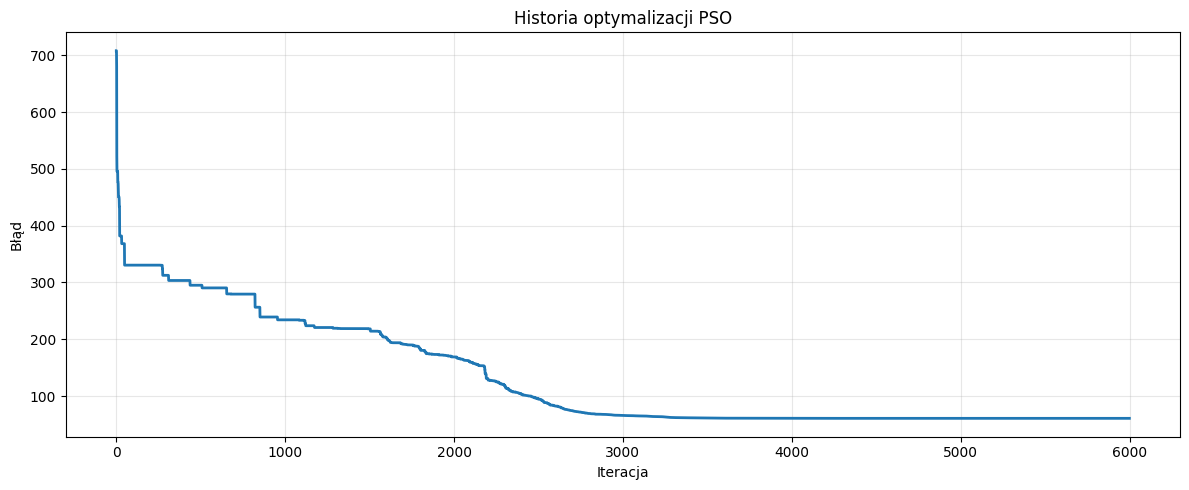

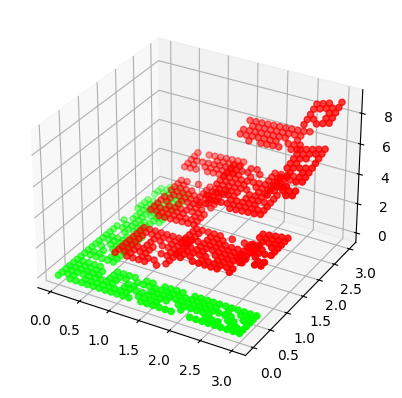

In [25]:
mf_list = [[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375],
                      [0.375, 0.4375, 0.5625, 0.625]]
labels = ["L", "M", "H"]

x = np.arange(0, 3.1, 0.1)
y = np.arange(0, 3.1, 0.1)
xx, yy = np.meshgrid(x, y)
n_samples = xx.size    

dataX = xx.flatten()
dataY = yy.flatten()
dataXY = np.column_stack((dataX, dataY))
data_labels = np.round(dataX) * np.round(dataY)
    
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(dataX, dataY, data_labels)
plt.show()

varX = FuzzyInputVariable_List_Trapezoids(mf_list, "XAxis", labels)
varY = FuzzyInputVariable_List_Trapezoids(mf_list, "YAxis", labels)

X_train, X_test, y_train, y_test = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)

anfis_pso = ANFIS([varX, varY], X_train.T, y_train, operator_init_value=0.5)

print("\nParametry przed uczeniem:")
print(f"Premises shape: {np.shape(anfis_pso.premises)}")
print(f"Operators length: {len(anfis_pso.op)}")
print(f"TSK shape: {np.shape(anfis_pso.tsk)}")

start = time.time()

fitness_history = anfis_pso.train(
    global_optimization=False,
    learn_premises=True,
    learn_operators=True,
    learn_consequents=True,
    n_iter=6000,  
    use_pso_algorithm=True,  
    pso_pop_size=60,
    c_bounds=(1.8, 2.8),
    pso_w=1.0
)

print("\n" + "=" * 70)
print("TRENING ZAKOŃCZONY!")
print("=" * 70)

result = anfis_pso.anfis_estimate_labels(anfis_pso.premises, anfis_pso.op, anfis_pso.tsk)
pred = result.ravel()
error = np.abs(pred - y_train).sum()
print(f"\nKońcowy błąd na zbiorze treningowym: {error:.6f}")

n_samples = len(y_train)
print(f"Średni błąd na próbkę: {error/n_samples:.6f}")

if fitness_history is not None:
    plt.figure(figsize=(12, 5))
    
    plt.plot(fitness_history, linewidth=2)
    plt.xlabel('Iteracja')
    plt.ylabel('Błąd')
    plt.title('Historia optymalizacji PSO')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

anfis_pso.show_results()